In [1]:
import os
import yaml
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import eurocropsml
from pathlib import Path
from tqdm.notebook import tqdm

Found 99634 PT files


Reading PT files:   0%|          | 0/99634 [00:00<?, ?file/s]

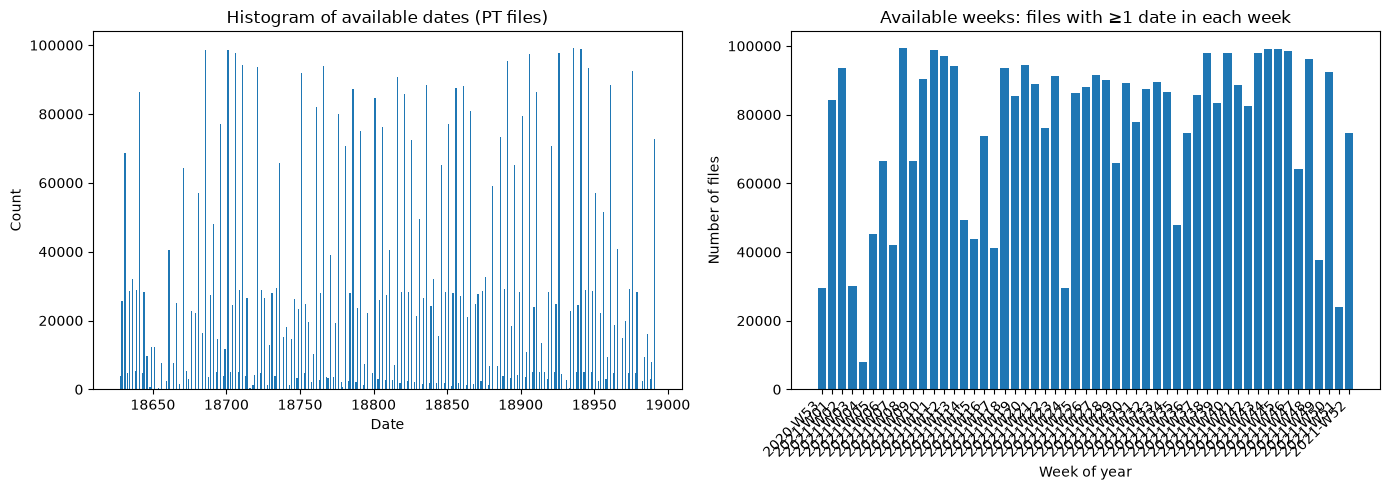

In [2]:
files = sorted(glob.glob("PT*.npz"))
print(f"Found {len(files)} PT files")

all_dates = []          # every date contained in every PT file
files_per_week = {}     # ISO week number -> number of files with >=1 date that week

for f in tqdm(files, desc="Reading PT files", unit="file"):
    with np.load(f, allow_pickle=True) as z:
        dates = np.atleast_1d(z["dates"]).astype("datetime64[D]")

    weeks = {
        (int(d.strftime("%G")), int(d.strftime("%V")))   # (ISO year, ISO week)
        for d in [np.datetime64(d, "D").astype("O") for d in []] # placeholder
    }
    # simpler: compute ISO week from datetime64 via datetime conversion
    import datetime as _dt
    weeks = set()
    for d in dates:
        do = d.astype("O") if not isinstance(d, _dt.datetime) else d
        if isinstance(do, np.datetime64):
            do = do.astype(_dt.date)
        iso = do.isocalendar()
        weeks.add((iso[0], iso[1]))

    all_dates.append(dates)
    for w in weeks:
        files_per_week[w] = files_per_week.get(w, 0) + 1

all_dates = np.concatenate(all_dates)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histogram of all available dates ---
unique_dates, counts = np.unique(all_dates, return_counts=True)
axes[0].bar(unique_dates.astype("datetime64[D]").astype("int64"), counts)
axes[0].set_title("Histogram of available dates (PT files)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Count")

# --- Histogram of available weeks ---
weeks = sorted(files_per_week)
labels = [f"{y}-W{w:02d}" for (y, w) in weeks]
axes[1].bar(range(len(weeks)), [files_per_week[w] for w in weeks])
axes[1].set_xticks(range(len(weeks)))
axes[1].set_xticklabels(labels, rotation=45, ha="right")
axes[1].set_title("Available weeks: files with ≥1 date in each week")
axes[1].set_xlabel("Week of year")
axes[1].set_ylabel("Number of files")

plt.tight_layout()
plt.show()

Found 175906 EE files


Reading EE files:   0%|          | 0/175906 [00:00<?, ?file/s]

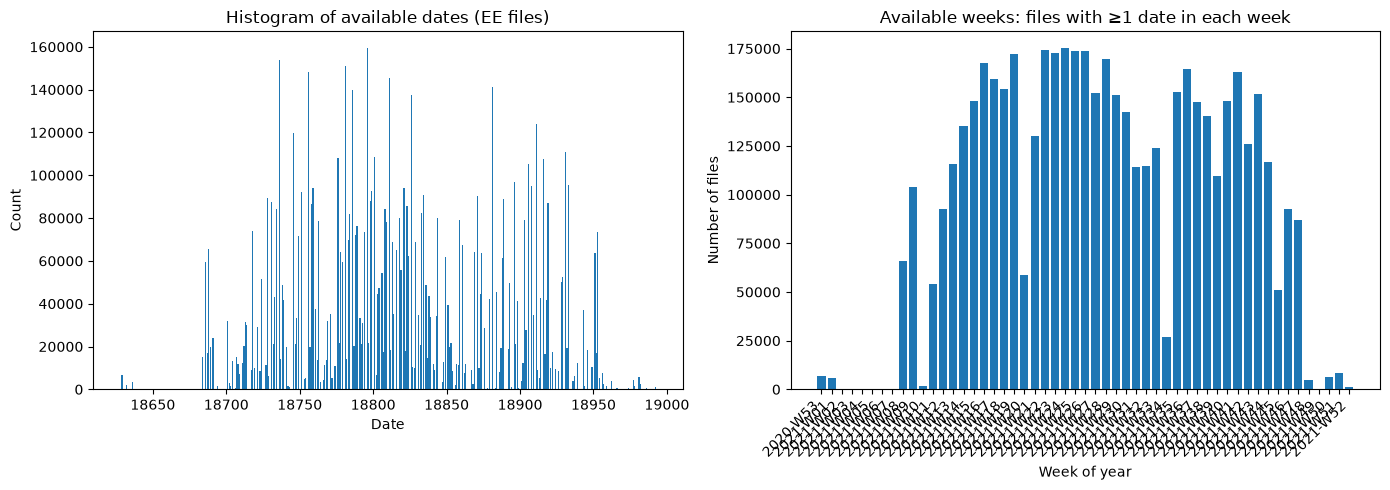

In [3]:
files = sorted(glob.glob("EE*.npz"))
print(f"Found {len(files)} EE files")

all_dates = []          # every date contained in every EE file
files_per_week = {}     # ISO week number -> number of files with >=1 date that week

for f in tqdm(files, desc="Reading EE files", unit="file"):
    with np.load(f, allow_pickle=True) as z:
        dates = np.atleast_1d(z["dates"]).astype("datetime64[D]")

    weeks = {
        (int(d.strftime("%G")), int(d.strftime("%V")))   # (ISO year, ISO week)
        for d in [np.datetime64(d, "D").astype("O") for d in []] # placeholder
    }
    # simpler: compute ISO week from datetime64 via datetime conversion
    import datetime as _dt
    weeks = set()
    for d in dates:
        do = d.astype("O") if not isinstance(d, _dt.datetime) else d
        if isinstance(do, np.datetime64):
            do = do.astype(_dt.date)
        iso = do.isocalendar()
        weeks.add((iso[0], iso[1]))

    all_dates.append(dates)
    for w in weeks:
        files_per_week[w] = files_per_week.get(w, 0) + 1

all_dates = np.concatenate(all_dates)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histogram of all available dates ---
unique_dates, counts = np.unique(all_dates, return_counts=True)
axes[0].bar(unique_dates.astype("datetime64[D]").astype("int64"), counts)
axes[0].set_title("Histogram of available dates (EE files)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Count")

# --- Histogram of available weeks ---
weeks = sorted(files_per_week)
labels = [f"{y}-W{w:02d}" for (y, w) in weeks]
axes[1].bar(range(len(weeks)), [files_per_week[w] for w in weeks])
axes[1].set_xticks(range(len(weeks)))
axes[1].set_xticklabels(labels, rotation=45, ha="right")
axes[1].set_title("Available weeks: files with ≥1 date in each week")
axes[1].set_xlabel("Week of year")
axes[1].set_ylabel("Number of files")

plt.tight_layout()
plt.show()

Found 431143 LV files


Reading LV files:   0%|          | 0/431143 [00:00<?, ?file/s]

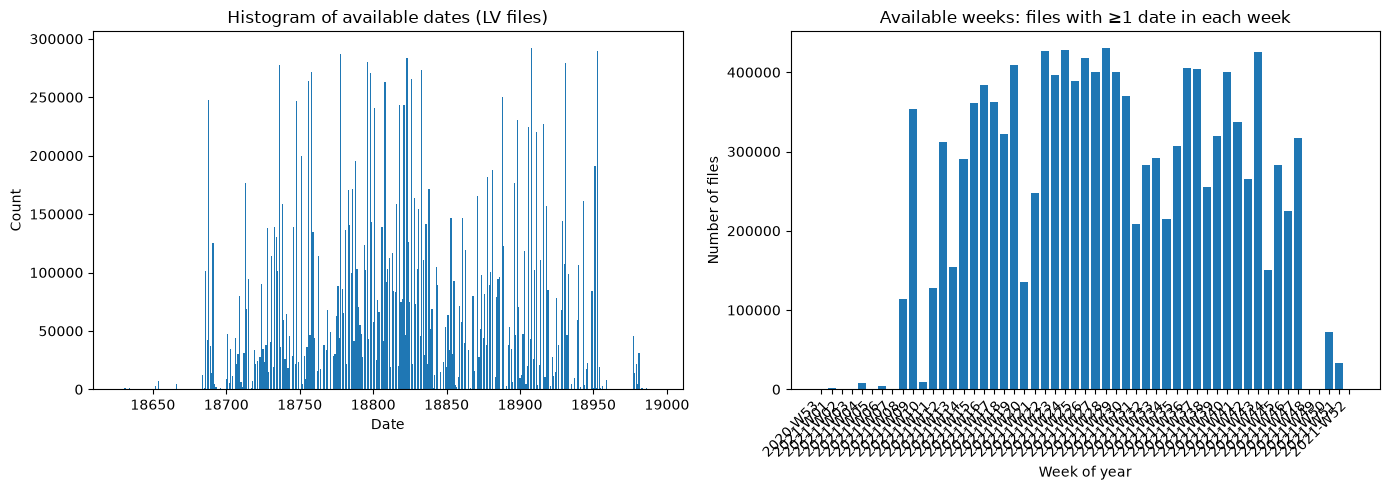

In [4]:
files = sorted(glob.glob("LV*.npz"))
print(f"Found {len(files)} LV files")

all_dates = []          # every date contained in every LV file
files_per_week = {}     # ISO week number -> number of files with >=1 date that week

for f in tqdm(files, desc="Reading LV files", unit="file"):
    with np.load(f, allow_pickle=True) as z:
        dates = np.atleast_1d(z["dates"]).astype("datetime64[D]")

    weeks = {
        (int(d.strftime("%G")), int(d.strftime("%V")))   # (ISO year, ISO week)
        for d in [np.datetime64(d, "D").astype("O") for d in []] # placeholder
    }
    # simpler: compute ISO week from datetime64 via datetime conversion
    import datetime as _dt
    weeks = set()
    for d in dates:
        do = d.astype("O") if not isinstance(d, _dt.datetime) else d
        if isinstance(do, np.datetime64):
            do = do.astype(_dt.date)
        iso = do.isocalendar()
        weeks.add((iso[0], iso[1]))

    all_dates.append(dates)
    for w in weeks:
        files_per_week[w] = files_per_week.get(w, 0) + 1

all_dates = np.concatenate(all_dates)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histogram of all available dates ---
unique_dates, counts = np.unique(all_dates, return_counts=True)
axes[0].bar(unique_dates.astype("datetime64[D]").astype("int64"), counts)
axes[0].set_title("Histogram of available dates (LV files)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Count")

# --- Histogram of available weeks ---
weeks = sorted(files_per_week)
labels = [f"{y}-W{w:02d}" for (y, w) in weeks]
axes[1].bar(range(len(weeks)), [files_per_week[w] for w in weeks])
axes[1].set_xticks(range(len(weeks)))
axes[1].set_xticklabels(labels, rotation=45, ha="right")
axes[1].set_title("Available weeks: files with ≥1 date in each week")
axes[1].set_xlabel("Week of year")
axes[1].set_ylabel("Number of files")

plt.tight_layout()
plt.show()